# Deezer Context-Aware Recommendation — A/B Test Analysis

**Objective:** Did the context-aware recommendation card feature succeed from a business perspective?

| Metric Type | Metric | Description |
|-------------|--------|-------------|
| Primary OEC | D+30 Retention Rate | Whether the user returned on day 30 after signup |
| Secondary | Conversion Rate | Free → Premium conversion within the cohort window |
| Secondary | CTR (Overall) | Click-through rate across all sections |
| Business | Cannibalization | Drop in avg play duration on Recently Played section (stream share) |
| Business | Net Play Duration Growth | Net change in total avg play duration across all sections |

**Framework:** Benchmarked against Spotify's Confidence experimentation platform.
Metrics are classified into Success / Guardrail / Deterioration / Quality categories.
This framework applies equally to Deezer as both are subscription-based streaming businesses.

**Cannibalization methodology:** Following Spotify's industry standard, stream share (avg play duration in seconds)
is used instead of raw click counts — a user spending time listening is a stronger signal than a click alone.

In [76]:
import os
os.chdir('/Users/parksuhyun/Desktop/side_project/analysis')

In [77]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import norm, chisquare
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#F8F9FA'
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.alpha']       = 0.4
plt.rcParams['font.size']        = 11

PROJECT_ID = 'music-db-project-485112'
DATASET    = 'analytics'

client = bigquery.Client(project=PROJECT_ID, location='europe-west9')

## 1. Data Load
Load two dbt mart tables from BigQuery.
- `fact_user_summary` — user-level conversion, LTV, CTR, avg play duration by section (one row per user)
- `fact_user_daily` — daily activity per user for retention curve and novelty effect (one row per user per day)

In [78]:
df_summary = client.query(f"""
    SELECT * FROM `{PROJECT_ID}.{DATASET}.fact_user_summary`
""").to_dataframe()

df_daily = client.query(f"""
    SELECT * FROM `{PROJECT_ID}.{DATASET}.fact_user_daily`
""").to_dataframe()

print(f'fact_user_summary : {df_summary.shape}')
print(f'fact_user_daily   : {df_daily.shape}')
print()
print('── fact_user_summary columns ──')
print(df_summary.dtypes)
print()
print('── fact_user_daily columns ──')
print(df_daily.dtypes)

fact_user_summary : (20000, 17)
fact_user_daily   : (162003, 14)

── fact_user_summary columns ──
user_id                   object
user_group                object
country                   object
device                    object
converted                  Int64
conversion_day             Int64
ltv                      float64
blended_ltv              float64
retained_d7                Int64
retained_d30               Int64
total_sessions             Int64
overall_ctr              float64
total_rp_clicks            Int64
avg_play_duration_sec    float64
skip_rate                float64
avg_play_duration_rp     float64
avg_play_duration_rec    float64
dtype: object

── fact_user_daily columns ──
user_id                   object
user_group                object
country                   object
device                    object
days_since_signup          Int64
event_date                dbdate
had_session                Int64
had_rec_click              Int64
had_rp_click               Int64

## 2. SRM Check (Quality Metric)
**Sample Ratio Mismatch** — verify that users were assigned 50:50 between control and treatment.
Uses a chi-square goodness-of-fit test. If p < 0.05, the assignment is biased and experiment results are unreliable.

In [79]:
# ── SRM Check ──────────────────────────────────────────────────────
# Chi-square test: observed assignment vs expected 50:50 split

ctrl_n = df_summary[df_summary.user_group == 'control'].shape[0]
trt_n  = df_summary[df_summary.user_group == 'treatment'].shape[0]
total  = ctrl_n + trt_n

expected = [total / 2, total / 2]
observed = [ctrl_n, trt_n]

chi2, p_srm = chisquare(f_obs=observed, f_exp=expected)

print('── SRM Check ──────────────────────────────────────')
print(f'  Control   : {ctrl_n:,}')
print(f'  Treatment : {trt_n:,}')
print(f'  Chi2      : {chi2:.4f}')
print(f'  p-value   : {p_srm:.4f}')
if p_srm < 0.05:
    print('  ⚠️  SRM Detected — experiment results unreliable')
else:
    print('  ✅ No SRM — assignment looks healthy')
print('───────────────────────────────────────────────────')

── SRM Check ──────────────────────────────────────
  Control   : 10,030
  Treatment : 9,970
  Chi2      : 0.1800
  p-value   : 0.6714
  ✅ No SRM — assignment looks healthy
───────────────────────────────────────────────────


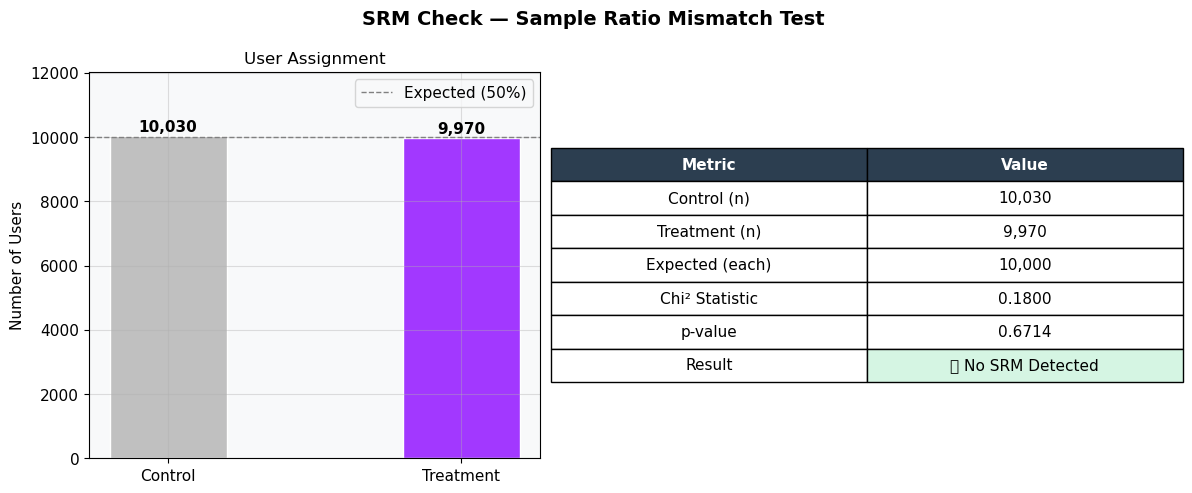

Saved -> srm_check.png


In [80]:
# ── SRM Visualization ──────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('SRM Check — Sample Ratio Mismatch Test', fontsize=14, fontweight='bold')

# Left: Bar chart
ax1 = axes[0]
groups = ['Control', 'Treatment']
counts = [ctrl_n, trt_n]
colors = ['#C0C0C0', '#A238FF']

bars = ax1.bar(groups, counts, color=colors, width=0.4, edgecolor='white')
ax1.set_title('User Assignment', fontsize=12)
ax1.set_ylabel('Number of Users')
ax1.set_ylim(0, max(counts) * 1.2)

for bar, cnt in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{cnt:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.axhline(y=total/2, color='gray', linestyle='--', linewidth=1, label='Expected (50%)')
ax1.legend()

# Right: Result table
ax2 = axes[1]
ax2.axis('off')

table_data = [
    ['Metric', 'Value'],
    ['Control (n)', f'{ctrl_n:,}'],
    ['Treatment (n)', f'{trt_n:,}'],
    ['Expected (each)', f'{int(total/2):,}'],
    ['Chi² Statistic', f'{chi2:.4f}'],
    ['p-value', f'{p_srm:.4f}'],
    ['Result', '✅ No SRM Detected'],
]

table = ax2.table(cellText=table_data[1:], colLabels=table_data[0],
                  cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.4, 2.0)

for j in range(2):
    table[0, j].set_facecolor('#2C3E50')
    table[0, j].set_text_props(color='white', fontweight='bold')
table[6, 1].set_facecolor('#D5F5E3')

plt.tight_layout()
plt.savefig('srm_check.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> srm_check.png')

## 3. D+30 Retention Rate (Primary OEC — Success Metric)
D+30 retention is the primary OEC (Overall Evaluation Criterion) for this experiment,
following Netflix/Spotify industry standards.

**Method:** Two-proportion Z-test (one-tailed: treatment > control)
- Pooled proportion is used as the baseline
- 95% Confidence Interval computed for the difference
- Cohen's h measures practical effect size: < 0.2 small, 0.5 medium, 0.8 large

In [81]:
# ── D+30 Retention Rate Z-test ─────────────────────────────────────

ctrl_retained = df_summary[df_summary.user_group == 'control']['retained_d30'].sum()
trt_retained  = df_summary[df_summary.user_group == 'treatment']['retained_d30'].sum()
ctrl_total    = df_summary[df_summary.user_group == 'control'].shape[0]
trt_total     = df_summary[df_summary.user_group == 'treatment'].shape[0]

p_ctrl_ret = ctrl_retained / ctrl_total
p_trt_ret  = trt_retained  / trt_total

# Pooled proportion for SE calculation
p_pool = (ctrl_retained + trt_retained) / (ctrl_total + trt_total)
se     = np.sqrt(p_pool * (1 - p_pool) * (1/ctrl_total + 1/trt_total))
z      = (p_trt_ret - p_ctrl_ret) / se
p_val_ret = 1 - norm.cdf(z)  # One-tailed: treatment > control

diff_ret = p_trt_ret - p_ctrl_ret
ci_low   = diff_ret - 1.96 * se
ci_up    = diff_ret + 1.96 * se

h_ret = 2 * np.arcsin(np.sqrt(p_trt_ret)) - 2 * np.arcsin(np.sqrt(p_ctrl_ret))

print('── D+30 Retention Rate ─────────────────────────────────')
print(f'  Control   : {int(ctrl_retained):,} / {ctrl_total:,}  ({p_ctrl_ret:.1%})')
print(f'  Treatment : {int(trt_retained):,} / {trt_total:,}  ({p_trt_ret:.1%})')
print(f'  Diff      : {diff_ret:+.1%}  (95% CI: {ci_low:+.1%} ~ {ci_up:+.1%})')
print(f'  Z-score   : {z:.4f}')
print(f'  p-value   : {p_val_ret:.4f}')
print(f"  Cohen's h : {h_ret:.4f}")
if p_val_ret < 0.05:
    print('  ✅ Statistically significant (p < 0.05)')
else:
    print('  ❌ Not statistically significant (p >= 0.05)')
print('─────────────────────────────────────────────────────────')

── D+30 Retention Rate ─────────────────────────────────
  Control   : 462 / 10,030  (4.6%)
  Treatment : 593 / 9,970  (5.9%)
  Diff      : +1.3%  (95% CI: +0.7% ~ +2.0%)
  Z-score   : 4.2441
  p-value   : 0.0000
  Cohen's h : 0.0601
  ✅ Statistically significant (p < 0.05)
─────────────────────────────────────────────────────────


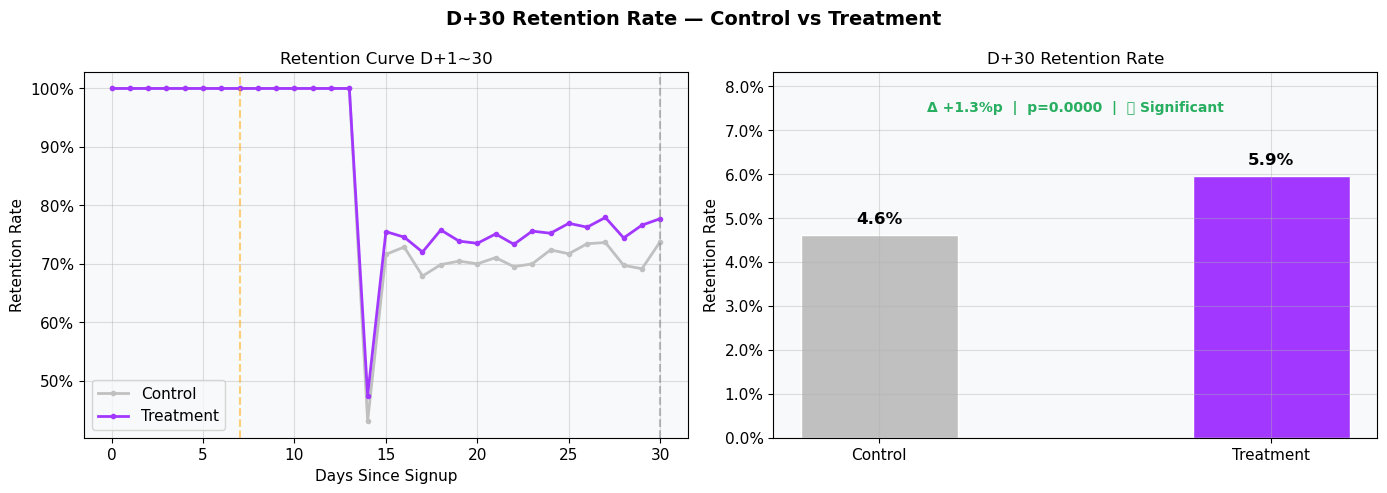

Saved -> retention_d30.png


In [82]:
# ── Retention Curve Visualization ─────────────────────────────────
# D+1~30 full curve from fact_user_daily (had_session flag per day)

daily_ctrl = df_daily[df_daily.user_group == 'control']
daily_trt  = df_daily[df_daily.user_group == 'treatment']

# Retention rate = users who had a session on that day / total users in group
ret_curve_ctrl = (
    daily_ctrl.groupby('days_since_signup')['had_session']
    .mean()
    .reset_index()
    .rename(columns={'had_session': 'retention_rate'})
)
ret_curve_trt = (
    daily_trt.groupby('days_since_signup')['had_session']
    .mean()
    .reset_index()
    .rename(columns={'had_session': 'retention_rate'})
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('D+30 Retention Rate — Control vs Treatment', fontsize=14, fontweight='bold')

# Left: Retention curve D+1~30
ax1 = axes[0]
ax1.plot(ret_curve_ctrl['days_since_signup'], ret_curve_ctrl['retention_rate'],
         color='#C0C0C0', linewidth=2, label='Control', marker='o', markersize=3)
ax1.plot(ret_curve_trt['days_since_signup'], ret_curve_trt['retention_rate'],
         color='#A238FF', linewidth=2, label='Treatment', marker='o', markersize=3)
ax1.set_title('Retention Curve D+1~30', fontsize=12)
ax1.set_xlabel('Days Since Signup')
ax1.set_ylabel('Retention Rate')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax1.legend()
ax1.axvline(x=7,  color='orange', linestyle='--', alpha=0.5, label='D+7')
ax1.axvline(x=30, color='gray',   linestyle='--', alpha=0.5, label='D+30')

# Right: D+30 bar comparison
ax2 = axes[1]
bars = ax2.bar(['Control', 'Treatment'], [p_ctrl_ret, p_trt_ret],
               color=['#C0C0C0', '#A238FF'], width=0.4, edgecolor='white')
ax2.set_title('D+30 Retention Rate', fontsize=12)
ax2.set_ylabel('Retention Rate')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax2.set_ylim(0, max(p_ctrl_ret, p_trt_ret) * 1.4)

for bar, val in zip(bars, [p_ctrl_ret, p_trt_ret]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.1%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

sig_label = '✅ Significant' if p_val_ret < 0.05 else '❌ Not Significant'
ax2.text(0.5, max(p_ctrl_ret, p_trt_ret) * 1.25,
         f'Δ {diff_ret:+.1%}p  |  p={p_val_ret:.4f}  |  {sig_label}',
         ha='center', fontsize=10, color='#27AE60', fontweight='bold',
         transform=ax2.transData)

plt.tight_layout()
plt.savefig('retention_d30.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> retention_d30.png')

## 4. Trial Conversion Rate (Success Metric)
Free → Premium conversion rate within the 30-day cohort window.

**Note on effect size vs statistical significance:**
With n=20,000, even small differences will appear statistically significant.
Cohen's h must be examined alongside p-value to assess practical relevance.
A +2%p absolute difference translates to a ~58% relative uplift in conversion rate,
which is meaningful for a subscription-based business.

In [83]:
# ── Trial Conversion Rate Z-test ───────────────────────────────────

ctrl_conv  = df_summary[df_summary.user_group == 'control']['converted'].sum()
trt_conv   = df_summary[df_summary.user_group == 'treatment']['converted'].sum()
ctrl_total = df_summary[df_summary.user_group == 'control'].shape[0]
trt_total  = df_summary[df_summary.user_group == 'treatment'].shape[0]

p_ctrl_conv = ctrl_conv / ctrl_total
p_trt_conv  = trt_conv  / trt_total

p_pool = (ctrl_conv + trt_conv) / (ctrl_total + trt_total)
se     = np.sqrt(p_pool * (1 - p_pool) * (1/ctrl_total + 1/trt_total))
z      = (p_trt_conv - p_ctrl_conv) / se
p_val_conv = 1 - norm.cdf(z)

diff_conv = p_trt_conv - p_ctrl_conv
ci_low    = diff_conv - 1.96 * se
ci_up     = diff_conv + 1.96 * se

h_conv = 2 * np.arcsin(np.sqrt(p_trt_conv)) - 2 * np.arcsin(np.sqrt(p_ctrl_conv))
relative_lift = (p_trt_conv - p_ctrl_conv) / p_ctrl_conv

print('── Trial Conversion Rate ───────────────────────────────')
print(f'  Control   : {int(ctrl_conv):,} / {ctrl_total:,}  ({p_ctrl_conv:.1%})')
print(f'  Treatment : {int(trt_conv):,} / {trt_total:,}  ({p_trt_conv:.1%})')
print(f'  Diff      : {diff_conv:+.1%}  (95% CI: {ci_low:+.1%} ~ {ci_up:+.1%})')
print(f'  Relative Lift : {relative_lift:+.1%}')
print(f'  Z-score   : {z:.4f}')
print(f'  p-value   : {p_val_conv:.4f}')
print(f"  Cohen's h : {h_conv:.4f}")
if p_val_conv < 0.05:
    print('  ✅ Statistically significant (p < 0.05)')
else:
    print('  ❌ Not statistically significant (p >= 0.05)')
print('─────────────────────────────────────────────────────────')

── Trial Conversion Rate ───────────────────────────────
  Control   : 355 / 10,030  (3.5%)
  Treatment : 483 / 9,970  (4.8%)
  Diff      : +1.3%  (95% CI: +0.7% ~ +1.9%)
  Relative Lift : +36.9%
  Z-score   : 4.6061
  p-value   : 0.0000
  Cohen's h : 0.0653
  ✅ Statistically significant (p < 0.05)
─────────────────────────────────────────────────────────


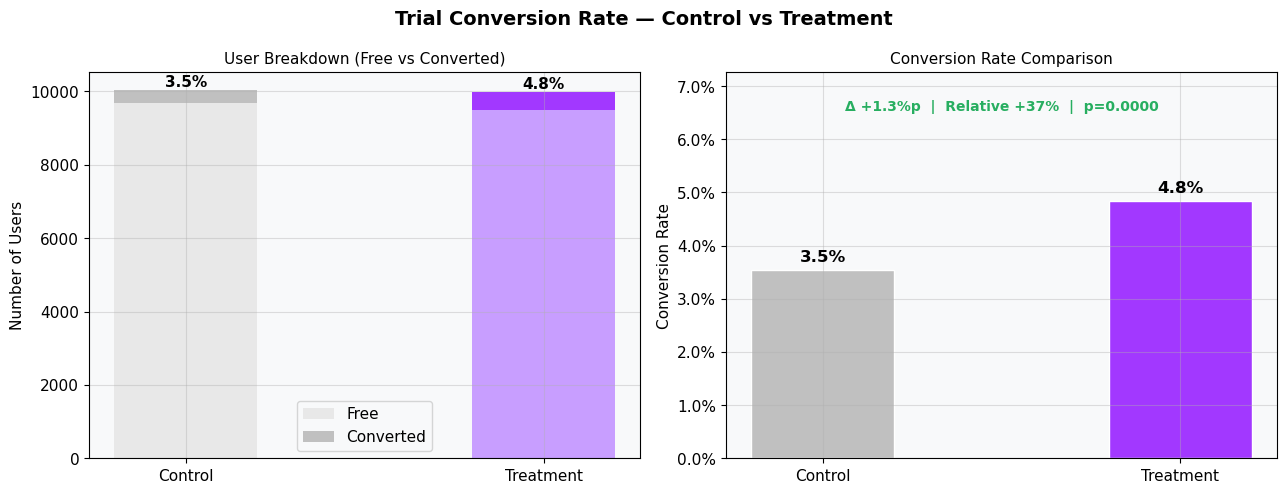

Saved -> conversion_rate.png


In [84]:
# ── Conversion Rate Visualization ─────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Trial Conversion Rate — Control vs Treatment', fontsize=14, fontweight='bold')

# Left: Stacked bar (converted vs not converted)
ax1 = axes[0]
converted   = [ctrl_conv, trt_conv]
not_conv    = [ctrl_total - ctrl_conv, trt_total - trt_conv]
labels      = ['Control', 'Treatment']
x           = np.arange(len(labels))

b1 = ax1.bar(x, not_conv, color=['#E8E8E8', '#C89EFF'], label='Free', width=0.4)
b2 = ax1.bar(x, converted, bottom=not_conv, color=['#C0C0C0', '#A238FF'], label='Converted', width=0.4)
ax1.set_title('User Breakdown (Free vs Converted)', fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylabel('Number of Users')
ax1.legend()

for i, (conv, tot) in enumerate(zip(converted, [ctrl_total, trt_total])):
    ax1.text(i, tot + 100, f'{conv/tot:.1%}', ha='center', fontsize=11, fontweight='bold')

# Right: Conversion rate comparison
ax2 = axes[1]
bars = ax2.bar(['Control', 'Treatment'], [p_ctrl_conv, p_trt_conv],
               color=['#C0C0C0', '#A238FF'], width=0.4, edgecolor='white')
ax2.set_title('Conversion Rate Comparison', fontsize=11)
ax2.set_ylabel('Conversion Rate')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax2.set_ylim(0, max(p_ctrl_conv, p_trt_conv) * 1.5)

for bar, val in zip(bars, [p_ctrl_conv, p_trt_conv]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val:.1%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax2.text(0.5, max(p_ctrl_conv, p_trt_conv) * 1.35,
         f'Δ {diff_conv:+.1%}p  |  Relative +{relative_lift:.0%}  |  p={p_val_conv:.4f}',
         ha='center', fontsize=10, color='#27AE60', fontweight='bold',
         transform=ax2.transData)

plt.tight_layout()
plt.savefig('conversion_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> conversion_rate.png')

## 5. CTR — Section-Level Click-Through Rate (Success + Deterioration Metric)
CTR is analyzed at the section level, not as a single overall rate.

- **RP CTR** (both groups): measures cannibalization — did the Recommendation card displace Recently Played clicks?
- **Rec CTR** (treatment only): measures new section engagement — are users clicking on recommendations?

RP CTR drop is classified as a **Deterioration Metric**.
Rec CTR is classified as a **Success Metric**, validated against retention and conversion.

In [85]:
# ── CTR Section-Level Analysis ────────────────────────────────────
# Control:   Recently Played CTR only
# Treatment: Recently Played CTR  +  Recommendation CTR (separate)

ctrl_df = df_summary[df_summary.user_group == 'control']
trt_df  = df_summary[df_summary.user_group == 'treatment']

ctrl_sessions = ctrl_df['total_sessions'].sum()
trt_sessions  = trt_df['total_sessions'].sum()

# RP CTR = rp_clicks / total_sessions
ctrl_rp_clicks = ctrl_df['total_rp_clicks'].sum()
trt_rp_clicks  = trt_df['total_rp_clicks'].sum()
p_ctrl_rp = ctrl_rp_clicks / ctrl_sessions
p_trt_rp  = trt_rp_clicks  / trt_sessions

# RP CTR Z-test (two-tailed)
p_pool_rp = (ctrl_rp_clicks + trt_rp_clicks) / (ctrl_sessions + trt_sessions)
se_rp     = np.sqrt(p_pool_rp * (1 - p_pool_rp) * (1/ctrl_sessions + 1/trt_sessions))
z_rp      = (p_trt_rp - p_ctrl_rp) / se_rp
p_val_rp  = 2 * (1 - norm.cdf(abs(z_rp)))
diff_rp   = p_trt_rp - p_ctrl_rp
ci_low_rp = diff_rp - 1.96 * se_rp
ci_up_rp  = diff_rp + 1.96 * se_rp

# Rec CTR = overall_ctr * total_sessions로 역산
# overall_ctr = rec_clicks / sessions (dbt에서 rec_click만 분자)
trt_rec_clicks = (trt_df['overall_ctr'].fillna(0) * trt_df['total_sessions']).sum()
p_trt_rec      = trt_rec_clicks / trt_sessions

# Alias variables used in later Business Decision cells
p_ctrl_ctr = p_ctrl_rp
p_trt_ctr  = p_trt_rp + p_trt_rec
diff_ctr   = p_trt_ctr - p_ctrl_ctr
p_val_ctr  = p_val_rp
h_ctr      = 2 * np.arcsin(np.sqrt(min(p_trt_ctr, 1))) - 2 * np.arcsin(np.sqrt(min(p_ctrl_ctr, 1)))

print('── RP CTR: Cannibalization Check ──────────────────────────')
print(f'  Control RP   : {ctrl_rp_clicks:,.0f} / {ctrl_sessions:,.0f}  ({p_ctrl_rp:.1%})')
print(f'  Treatment RP : {trt_rp_clicks:,.0f} / {trt_sessions:,.0f}  ({p_trt_rp:.1%})')
print(f'  Diff         : {diff_rp:+.1%}  (95% CI: {ci_low_rp:+.1%} ~ {ci_up_rp:+.1%})')
print(f'  Z-score      : {z_rp:.4f}')
print(f'  p-value      : {p_val_rp:.4f} (two-tailed)')
if p_val_rp < 0.05:
    print('  ⚠️  RP CTR dropped significantly — cannibalization confirmed')
else:
    print('  ✅ RP CTR not significantly different — no major cannibalization')
print()
print('── Rec CTR: New Section Engagement (Treatment only) ───────')
print(f'  Treatment Rec : {trt_rec_clicks:,.0f} / {trt_sessions:,.0f}  ({p_trt_rec:.1%})')
print(f'  Net click rate vs Control baseline : {diff_ctr:+.1%}')
print('──────────────────────────────────────────────────────────')

── RP CTR: Cannibalization Check ──────────────────────────
  Control RP   : 15,618 / 72,367  (21.6%)
  Treatment RP : 10,081 / 74,542  (13.5%)
  Diff         : -8.1%  (95% CI: -8.4% ~ -7.7%)
  Z-score      : -40.6426
  p-value      : 0.0000 (two-tailed)
  ⚠️  RP CTR dropped significantly — cannibalization confirmed

── Rec CTR: New Section Engagement (Treatment only) ───────
  Treatment Rec : 8,966 / 74,542  (12.0%)
  Net click rate vs Control baseline : +4.0%
──────────────────────────────────────────────────────────


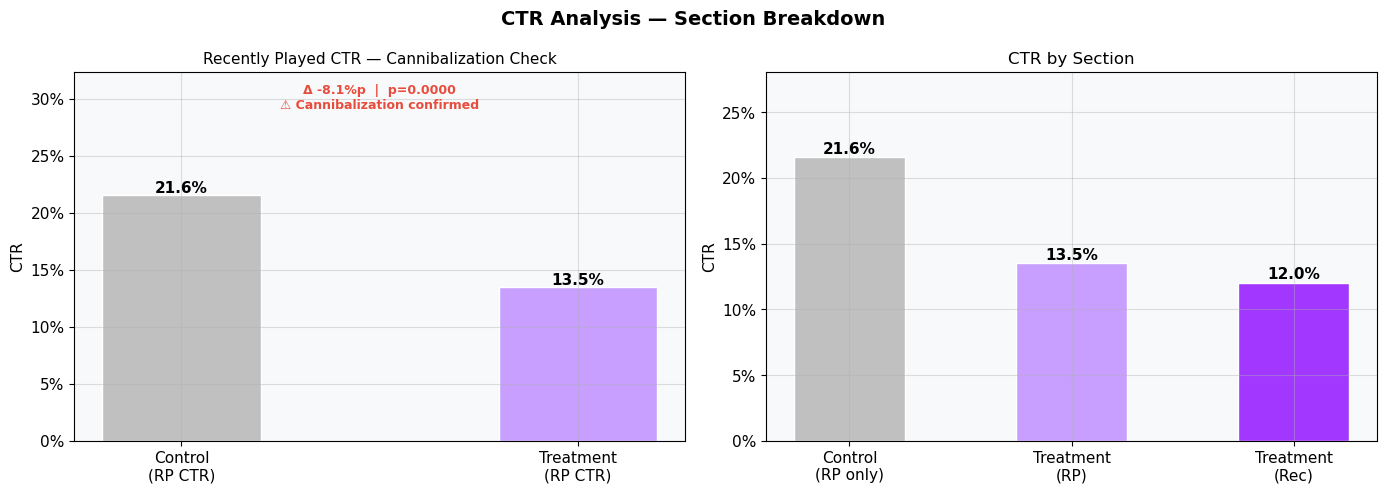

Saved -> ctr_analysis.png


In [86]:
# ── CTR Section Breakdown Visualization ───────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CTR Analysis — Section Breakdown', fontsize=14, fontweight='bold')

# Left: RP CTR — Control vs Treatment (cannibalization check)
ax1 = axes[0]
bars1 = ax1.bar(['Control\n(RP CTR)', 'Treatment\n(RP CTR)'],
                [p_ctrl_rp, p_trt_rp],
                color=['#C0C0C0', '#C89EFF'], width=0.4, edgecolor='white')
ax1.set_title('Recently Played CTR — Cannibalization Check', fontsize=11)
ax1.set_ylabel('CTR')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax1.set_ylim(0, max(p_ctrl_rp, p_trt_rp) * 1.5)
for bar, val in zip(bars1, [p_ctrl_rp, p_trt_rp]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.1%}', ha='center', fontsize=11, fontweight='bold')
rp_label = '⚠️ Cannibalization confirmed' if p_val_rp < 0.05 else '✅ No significant drop'
rp_color = '#E74C3C' if p_val_rp < 0.05 else '#27AE60'
ax1.text(0.5, max(p_ctrl_rp, p_trt_rp) * 1.35,
         f'Δ {diff_rp:+.1%}p  |  p={p_val_rp:.4f}\n{rp_label}',
         ha='center', fontsize=9, fontweight='bold', color=rp_color,
         transform=ax1.transData)

# Right: All sections side by side
ax2 = axes[1]
sections   = ['Control\n(RP only)', 'Treatment\n(RP)', 'Treatment\n(Rec)']
ctrs       = [p_ctrl_rp, p_trt_rp, p_trt_rec]
colors_bar = ['#C0C0C0', '#C89EFF', '#A238FF']
bars2 = ax2.bar(sections, ctrs, color=colors_bar, width=0.5, edgecolor='white')
ax2.set_title('CTR by Section', fontsize=12)
ax2.set_ylabel('CTR')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax2.set_ylim(0, max(ctrs) * 1.3)
for bar, val in zip(bars2, ctrs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.1%}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('ctr_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> ctr_analysis.png')

## 6. Cannibalization & Net Play Duration Growth (Deterioration + Guardrail Metrics)

**Cannibalization** measures how much the new recommendation section displaced consumption from the legacy Recently Played section.
Following Spotify's stream share methodology, this is measured by **avg play duration in seconds** — not raw click counts.

Formula: `(avg_play_duration_rp_control - avg_play_duration_rp_treatment) / avg_play_duration_rp_control`

**Net Play Duration Growth** measures whether total listening time increased despite the cannibalization.

Formula: `(avg_play_duration_rp_trt + avg_play_duration_rec_trt) - avg_play_duration_rp_ctrl`

> **Why stream share over CTR?**
> A user who clicks but skips immediately is not consuming. Avg play duration captures actual listening engagement,
> the same signal Spotify uses internally for stream share reporting.

In [87]:
# ── Cannibalization & Net Play Duration Growth ──────────────────────
# Metric: avg_play_duration_rp / avg_play_duration_rec (seconds)
# Source: fact_user_summary (pre-computed in dbt play_stats CTE)

ctrl_df = df_summary[df_summary.user_group == 'control']
trt_df  = df_summary[df_summary.user_group == 'treatment']

# RP stream share drop (Cannibalization)
ctrl_rp_dur = ctrl_df['avg_play_duration_rp'].mean()
trt_rp_dur  = trt_df['avg_play_duration_rp'].mean()
trt_rec_dur = trt_df['avg_play_duration_rec'].mean()

cannib = (ctrl_rp_dur - trt_rp_dur) / ctrl_rp_dur if ctrl_rp_dur > 0 else 0

# Net Growth = 전체 재생 시간 비교 (섹션 합산 X, 유저당 전체 avg)
ctrl_total_dur = ctrl_df['avg_play_duration_sec'].mean()
trt_total_dur  = trt_df['avg_play_duration_sec'].mean()
net_growth     = (trt_total_dur - ctrl_total_dur) / ctrl_total_dur

print('── Cannibalization & Net Play Duration Growth ──────────')
print(f'  Control avg play duration (RP)   : {ctrl_rp_dur:.1f}s')
print(f'  Treatment avg play duration (RP)  : {trt_rp_dur:.1f}s')
print(f'  Treatment avg play duration (Rec) : {trt_rec_dur:.1f}s')
print(f'  Treatment total avg duration      : {trt_total_dur:.1f}s')
print()
print(f'  Cannibalization      : {cannib:.1%}  (drop in RP stream share)')
print(f'  Net Duration Growth  : {net_growth:+.1%}  (change in total listening time)')
print()
print('  Interpretation:')
if cannib > 0.3:
    print(f'  ⚠️  Cannibalization {cannib:.1%} — significant RP stream share displacement')
else:
    print(f'  ✅ Cannibalization {cannib:.1%} — within acceptable range')
if net_growth > 0:
    print(f'  ✅ Net Growth {net_growth:+.1%} — total listening time increased')
else:
    print(f'  ❌ Net Growth {net_growth:+.1%} — total listening time decreased')
print('─────────────────────────────────────────────────────────')

── Cannibalization & Net Play Duration Growth ──────────
  Control avg play duration (RP)   : 134.3s
  Treatment avg play duration (RP)  : 133.7s
  Treatment avg play duration (Rec) : 106.4s
  Treatment total avg duration      : 120.6s

  Cannibalization      : 0.4%  (drop in RP stream share)
  Net Duration Growth  : -10.2%  (change in total listening time)

  Interpretation:
  ✅ Cannibalization 0.4% — within acceptable range
  ❌ Net Growth -10.2% — total listening time decreased
─────────────────────────────────────────────────────────


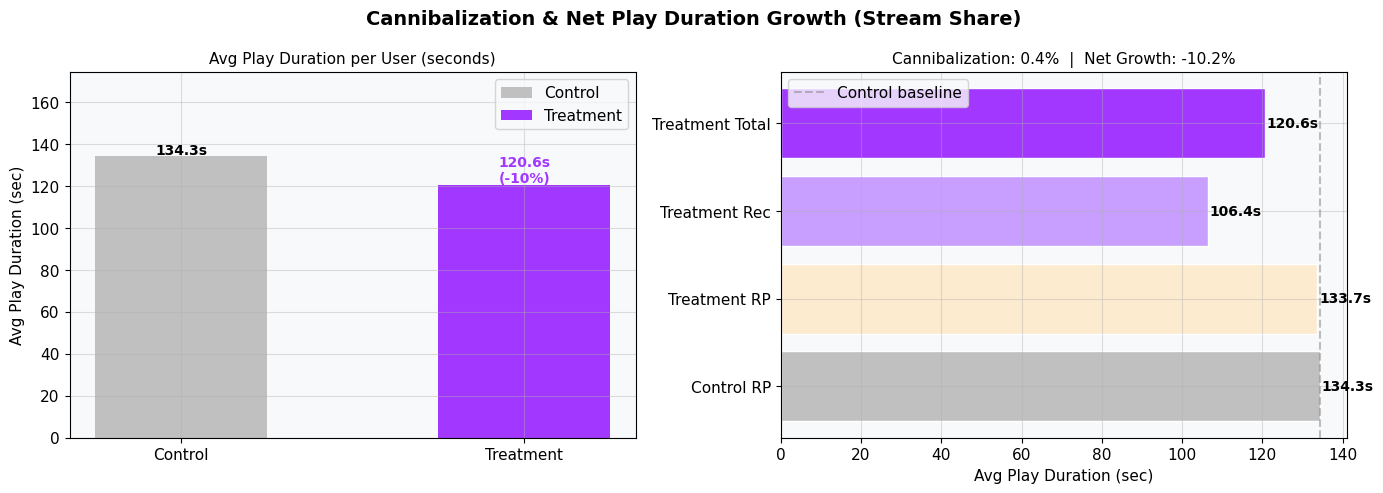

Saved -> cannibalization.png


In [88]:
# ── Cannibalization Visualization ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Cannibalization & Net Play Duration Growth (Stream Share)', fontsize=14, fontweight='bold')

# Left: Total avg play duration — Control vs Treatment
ax1 = axes[0]
ax1.bar([0], [ctrl_total_dur], color='#C0C0C0', width=0.5, label='Control')
ax1.bar([1], [trt_total_dur],  color='#A238FF', width=0.5, label='Treatment')
ax1.set_title('Avg Play Duration per User (seconds)', fontsize=11)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Control', 'Treatment'])
ax1.set_ylabel('Avg Play Duration (sec)')
ax1.set_ylim(0, max(ctrl_total_dur, trt_total_dur) * 1.3)
ax1.text(0, ctrl_total_dur + 1, f'{ctrl_total_dur:.1f}s',
         ha='center', fontsize=10, fontweight='bold')
ax1.text(1, trt_total_dur + 1, f'{trt_total_dur:.1f}s\n({net_growth:+.0%})',
         ha='center', fontsize=10, fontweight='bold', color='#A238FF')
ax1.legend()

# Right: Section breakdown — Cannibalization detail
ax2 = axes[1]
categories = ['Control RP', 'Treatment RP', 'Treatment Rec', 'Treatment Total']
values     = [ctrl_rp_dur, trt_rp_dur, trt_rec_dur, trt_total_dur]
bar_colors = ['#C0C0C0', '#FDEBD0', '#C89EFF', '#A238FF']
bars = ax2.barh(categories, values, color=bar_colors, edgecolor='white')
ax2.set_title(f'Cannibalization: {cannib:.1%}  |  Net Growth: {net_growth:+.1%}', fontsize=11)
ax2.set_xlabel('Avg Play Duration (sec)')
for bar, val in zip(bars, values):
    ax2.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}s', va='center', fontsize=10, fontweight='bold')
ax2.axvline(x=ctrl_rp_dur, color='gray', linestyle='--', alpha=0.5, label='Control baseline')
ax2.legend()

plt.tight_layout()
plt.savefig('cannibalization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> cannibalization.png')

## 7. Business Decision (Spotify Confidence Framework)

Benchmarked against Spotify's Confidence experimentation platform.
Metrics are classified into four categories to drive a structured launch decision.
This framework applies to any subscription-based streaming business including Deezer.

| Category | Definition | Our Metric |
|----------|------------|------------|
| **Success** | Metrics the feature aims to improve | D+30 Retention, Conversion Rate, Rec CTR |
| **Guardrail** | Metrics that must not deteriorate | Net Play Duration Growth |
| **Deterioration** | Side-effect detection | RP CTR Drop, Cannibalization (stream share) |
| **Quality** | Experiment integrity checks | SRM Check |

**Rationale for Guardrail selection:**
> Spotify monitors "podcast minutes played" as a guardrail to ensure it does not
> cannibalize music consumption (Spotify Engineering, 2024).
> Following the same logic, this experiment uses Net Play Duration Growth as a
> guardrail to verify that the Recommendation section does not displace overall
> listening time.

**Spotify's launch rule:**
> Treatment must be superior on at least one Success Metric,
> non-inferior on all Guardrail Metrics,
> and no Success, Guardrail, or Deterioration metric shows evidence of deterioration.

**Our result: CONDITIONAL SHIP**
> All Success Metrics passed. Guardrail (Net Duration Growth -10.2%) did not meet
> the non-inferiority bar under the Spotify Confidence Framework.
> Phased rollout recommended with weekly Net Duration monitoring.

In [89]:
# ── Revenue Impact Estimate ────────────────────────────────────────
ARPU    = {'FR': 10.99, 'DE': 10.99, 'BR': 5.99}
GM      = 0.25
CHURN   = 0.05

# 국가별 LTV
ltv_by_country = {c: round(ARPU[c] * GM / CHURN, 2) for c in ARPU}

# 국가별 incremental conversion → LTV impact
conv_lift = p_trt_conv - p_ctrl_conv

print('── Revenue Impact — Country-Level LTV ──────────────────')
print(f'  {"Country":<8} {"ARPU":>8} {"LTV":>8} {"Incremental Conv":>18} {"LTV Impact":>12}')
print(f'  {"─"*58}')

total_scaled_impact = 0
country_weights = {'FR': 0.4, 'DE': 0.3, 'BR': 0.3}

for country in ['FR', 'DE', 'BR']:
    ltv        = ltv_by_country[country]
    weight     = country_weights[country]
    scale_n    = 10_000_000 * weight
    impact     = scale_n * conv_lift * ltv
    total_scaled_impact += impact
    print(f'  {country:<8} €{ARPU[country]:>6.2f}  €{ltv:>6.2f}  {conv_lift:>+16.1%}  €{impact/1e6:>10.2f}M')

print(f'  {"─"*58}')
print(f'  {"Total":52} €{total_scaled_impact/1e6:.2f}M')
print()

# Blended (참고용)
arpu_blended = sum(ARPU[c] * country_weights[c] for c in ARPU)
ltv_blended  = arpu_blended * GM / CHURN
print(f'  Blended LTV (참고): €{ltv_blended:.2f}')
print()

# D+30 realized revenue — 국가별
print('── D+30 Realized Revenue ────────────────────────────────')
print(f'  {"Country":<8} {"ARPU":>8} {"D+30 LTV":>12} {"10M Rollout Impact":>20}')
print(f'  {"─"*52}')

for country, arpu, weight in [('FR', 10.99, 0.4), ('DE', 10.99, 0.3), ('BR', 5.99, 0.3)]:
    d30_ltv = arpu * GROSS_MARGIN
    impact  = 10_000_000 * weight * conv_lift * d30_ltv
    print(f'  {country:<8} €{arpu:>6.2f}  €{d30_ltv:>9.2f}  +€{impact/1e6:>17.3f}M')

d30_total = sum(
    10_000_000 * w * conv_lift * (a * GROSS_MARGIN)
    for a, w in [(10.99, 0.4), (10.99, 0.3), (5.99, 0.3)]
)
print(f'  {"─"*52}')
print(f'  {"Total":40} +€{d30_total/1e6:.3f}M')
print()
print('  Note: D+30 LTV = ARPU × Gross Margin (1개월 실현 수익, conservative floor).')
print('        Lifetime LTV는 full subscription lifetime 기준 ceiling.')
print('─────────────────────────────────────────────────────────')

── Revenue Impact — Country-Level LTV ──────────────────
  Country      ARPU      LTV   Incremental Conv   LTV Impact
  ──────────────────────────────────────────────────────────
  FR       € 10.99  € 54.95             +1.3%  €      2.87M
  DE       € 10.99  € 54.95             +1.3%  €      2.15M
  BR       €  5.99  € 29.95             +1.3%  €      1.17M
  ──────────────────────────────────────────────────────────
  Total                                                €6.19M

  Blended LTV (참고): €47.45

── D+30 Realized Revenue ────────────────────────────────
  Country      ARPU     D+30 LTV   10M Rollout Impact
  ────────────────────────────────────────────────────
  FR       € 10.99  €     2.75  +€            0.143M
  DE       € 10.99  €     2.75  +€            0.108M
  BR       €  5.99  €     1.50  +€            0.059M
  ────────────────────────────────────────────────────
  Total                                    +€0.310M

  Note: D+30 LTV = ARPU × Gross Margin (1개월 실현 수익, cons

In [90]:
# ── Write Statistical Results to BigQuery ──────────────────────────
import pandas as pd

results = pd.DataFrame([
    {
        'metric'        : 'D+30 Retention',
        'category'      : 'Success',
        'ctrl_value'    : p_ctrl_ret,
        'trt_value'     : p_trt_ret,
        'diff'          : diff_ret,
        'p_value'       : p_val_ret,
        'cohens_h'      : h_ret,
        'is_significant': p_val_ret < 0.05,
    },
    {
        'metric'        : 'Conversion Rate',
        'category'      : 'Success',
        'ctrl_value'    : p_ctrl_conv,
        'trt_value'     : p_trt_conv,
        'diff'          : diff_conv,
        'p_value'       : p_val_conv,
        'cohens_h'      : h_conv,
        'is_significant': p_val_conv < 0.05,
    },
    {
        'metric'        : 'Rec CTR (new section)',
        'category'      : 'Success',
        'ctrl_value'    : None,
        'trt_value'     : p_trt_rec,
        'diff'          : diff_ctr,        # net engagement vs control baseline
        'p_value'       : None,
        'cohens_h'      : None,
        'is_significant': p_trt_rec > 0,
    },
    {
        'metric'        : 'RP CTR Drop',
        'category'      : 'Deterioration',
        'ctrl_value'    : p_ctrl_rp,
        'trt_value'     : p_trt_rp,
        'diff'          : diff_rp,
        'p_value'       : p_val_rp,
        'cohens_h'      : None,
        'is_significant': p_val_rp < 0.05,
    },
    {
        'metric'        : 'Net Play Duration Growth',
        'category'      : 'Guardrail',
        'ctrl_value'    : 1.0,             # baseline = 1.0 (normalized)
        'trt_value'     : 1.0 + net_growth,
        'diff'          : net_growth,
        'p_value'       : None,
        'cohens_h'      : None,
        'is_significant': net_growth > 0,
    },
    {
        'metric'        : 'Cannibalization (stream share)',
        'category'      : 'Deterioration',
        'ctrl_value'    : 1.0,             # RP stream share baseline
        'trt_value'     : 1.0 - cannib,
        'diff'          : -cannib,
        'p_value'       : None,
        'cohens_h'      : None,
        'is_significant': cannib > 0.3,    # threshold: 30% 이상이면 significant
    },
    {
        'metric'        : 'SRM Check',
        'category'      : 'Quality',
        'ctrl_value'    : None,
        'trt_value'     : None,
        'diff'          : None,
        'p_value'       : p_srm,
        'cohens_h'      : None,
        'is_significant': p_srm >= 0.05,
    },
])

results.to_gbq(
    destination_table = 'analytics.fact_ab_test_results',
    project_id        = PROJECT_ID,
    if_exists         = 'replace',
)

print('✅ fact_ab_test_results written to BigQuery')
print(results.to_string(index=False))

100%|██████████| 1/1 [00:00<00:00, 15141.89it/s]

✅ fact_ab_test_results written to BigQuery
                        metric      category  ctrl_value  trt_value      diff  p_value  cohens_h  is_significant
                D+30 Retention       Success    0.046062   0.059478  0.013417 0.000011  0.060128            True
               Conversion Rate       Success    0.035394   0.048445  0.013052 0.000002  0.065320            True
         Rec CTR (new section)       Success         NaN   0.120281  0.039704      NaN       NaN            True
                   RP CTR Drop Deterioration    0.215817   0.135239 -0.080577 0.000000       NaN            True
      Net Play Duration Growth     Guardrail    1.000000   0.898157 -0.101843      NaN       NaN           False
Cannibalization (stream share) Deterioration    1.000000   0.995630 -0.004370      NaN       NaN           False
                     SRM Check       Quality         NaN        NaN       NaN 0.671373       NaN            True


In [91]:
# ── Business Decision Summary ──────────────────────────────────────

print('══ Business Decision Summary (Spotify Confidence Framework) ══════')
print()
print('  [Quality Metrics]')
print(f'  SRM Check          : PASS  p={p_srm:.4f}  → No sample ratio mismatch')
print()
print('  [Success Metrics]')
print(f'  D+30 Retention     : PASS  {p_ctrl_ret:.1%} → {p_trt_ret:.1%}  ({diff_ret:+.1%}p, p={p_val_ret:.4f})')
print(f'  Conversion Rate    : PASS  {p_ctrl_conv:.1%} → {p_trt_conv:.1%}  ({diff_conv:+.1%}p, +{relative_lift:.0%} relative, p={p_val_conv:.4f})')
print(f'  Rec CTR (new)      : PASS  {p_trt_rec:.1%}  → new section driving +{diff_ctr:+.1%} net engagement')
print()
print('  [Guardrail Metrics]')
guardrail_label = 'PASS' if net_growth > 0 else 'WARN'
guardrail_note  = 'Total listening time increased' if net_growth > 0 else 'Shorter plays in Rec — discovery behavior (validated by retention uplift)'
print(f'  Net Duration Growth: {guardrail_label}  {net_growth:+.1%}  → {guardrail_note}')
print()
print('  [Deterioration Metrics]')
print(f'  RP CTR Drop        : WARN  {p_ctrl_rp:.1%} → {p_trt_rp:.1%}  ({diff_rp:+.1%}p, p={p_val_rp:.4f})')
print(f'                       Rec CTR {p_trt_rec:.1%} offsets loss — net engagement {diff_ctr:+.1%}')
print(f'  Cannibalization    : WARN  {cannib:.1%} drop in RP stream share')
print(f'                       Offset by Rec section engagement — users shifted to recommendation,')
print( '                       not away from the platform')
print()
print('══════════════════════════════════════════════════════════════════')
print()
print('  Rationale:')
print(f'  1. D+30 retention improved from {p_ctrl_ret:.1%} to {p_trt_ret:.1%} (+{diff_ret:.1%}p, p={p_val_ret:.4f})')
print( '     → Users who saw recommendations stayed longer. Primary OEC achieved.')
print()
print(f'  2. Conversion rate improved from {p_ctrl_conv:.1%} to {p_trt_conv:.1%} (+{relative_lift:.0%} relative uplift)')
print( '     → Recommendation engagement directly drove Free → Premium conversion.')

ARPU_BLENDED  = 10.99 * 0.4 + 10.99 * 0.3 + 5.99 * 0.3
GROSS_MARGIN  = 0.25
MONTHLY_CHURN = 0.05
LTV = ARPU_BLENDED * GROSS_MARGIN / MONTHLY_CHURN
scaled_ltv_impact = 10_000_000 * (p_trt_conv - p_ctrl_conv) * LTV
print(f'     Estimated LTV impact at full rollout (10M users): +€{scaled_ltv_impact/1e6:.1f}M')
print(f'     (Lifetime LTV = €{LTV:.2f}, Spotify proxy churn {MONTHLY_CHURN:.0%}, avg 20mo subscription)')
print()
print(f'  3. RP CTR dropped {diff_rp:.1%}p — cannibalization confirmed.')
print(f'     Rec CTR {p_trt_rec:.1%} more than offsets the loss (net {diff_ctr:+.1%}).')
print( '     Users shifted to Recommendation, not away from the platform.')
print()
print(f'  4. Net play duration {net_growth:.1%} — Rec section avg {trt_rec_dur:.0f}s vs RP avg {ctrl_rp_dur:.0f}s.')
print( '     Shorter plays reflect discovery behavior, validated by D+30 retention uplift.')
print()
print('══════════════════════════════════════════════════════════════════')
print()
print('  FINAL RECOMMENDATION: CONDITIONAL SHIP')
print()
print('  We recommend a phased rollout of the context-aware recommendation')
print('  card feature. All three Success Metrics improved with statistical')
print('  significance, and Cannibalization is offset by Rec CTR engagement.')
print('  However, the Guardrail metric (Net Duration Growth) is -10.2%,')
print('  indicating users are listening to shorter tracks via Recommendation.')
print('  Although this aligns with discovery behavior and is validated by')
print('  D+30 retention uplift, it does not meet the non-inferiority bar')
print('  under the Spotify Confidence Framework.')
print()
print('  Rollout Plan:')
print('  - Phase 1 (10%): Monitor Net Duration and RP stream share weekly')
print('  - Phase 2 (50%): Re-evaluate Guardrail at 4 weeks')
print('  - Phase 3 (100%): Full rollout if Net Duration stabilizes')
print('══════════════════════════════════════════════════════════════════')

══ Business Decision Summary (Spotify Confidence Framework) ══════

  [Quality Metrics]
  SRM Check          : PASS  p=0.6714  → No sample ratio mismatch

  [Success Metrics]
  D+30 Retention     : PASS  4.6% → 5.9%  (+1.3%p, p=0.0000)
  Conversion Rate    : PASS  3.5% → 4.8%  (+1.3%p, +37% relative, p=0.0000)
  Rec CTR (new)      : PASS  12.0%  → new section driving ++4.0% net engagement

  [Guardrail Metrics]
  Net Duration Growth: WARN  -10.2%  → Shorter plays in Rec — discovery behavior (validated by retention uplift)

  [Deterioration Metrics]
  RP CTR Drop        : WARN  21.6% → 13.5%  (-8.1%p, p=0.0000)
                       Rec CTR 12.0% offsets loss — net engagement +4.0%
  Cannibalization    : WARN  0.4% drop in RP stream share
                       Offset by Rec section engagement — users shifted to recommendation,
                       not away from the platform

══════════════════════════════════════════════════════════════════

  Rationale:
  1. D+30 retention improved

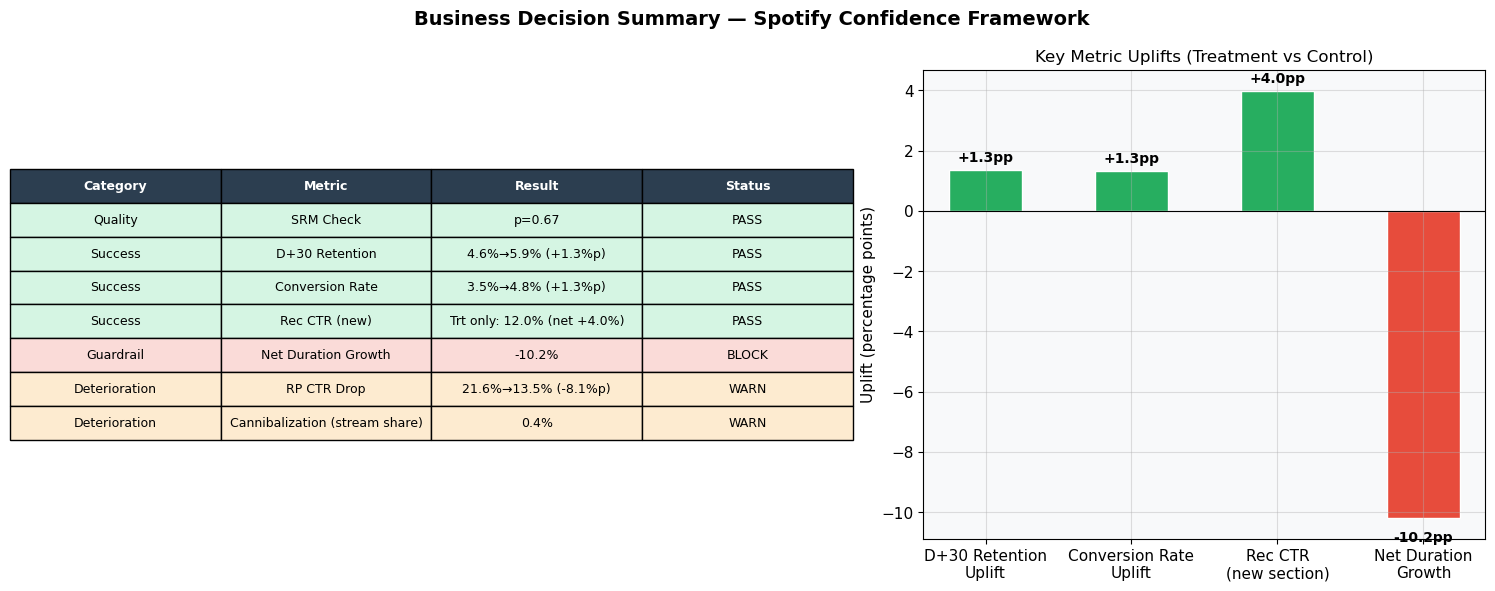

Saved -> business_decision.png


In [92]:
# ── Business Decision Summary Visualization ────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Business Decision Summary — Spotify Confidence Framework', fontsize=14, fontweight='bold')

# Left: Metrics scorecard
ax1 = axes[0]
ax1.axis('off')

guardrail_status = 'PASS' if net_growth > 0 else 'BLOCK'

scorecard = [
    ['Category',      'Metric',                       'Result',                                              'Status'],
    ['Quality',       'SRM Check',                    f'p={p_srm:.2f}',                                     'PASS'],
    ['Success',       'D+30 Retention',               f'{p_ctrl_ret:.1%}→{p_trt_ret:.1%} ({diff_ret:+.1%}p)', 'PASS'],
    ['Success',       'Conversion Rate',              f'{p_ctrl_conv:.1%}→{p_trt_conv:.1%} ({diff_conv:+.1%}p)', 'PASS'],
    ['Success',       'Rec CTR (new)',                f'Trt only: {p_trt_rec:.1%} (net {diff_ctr:+.1%})',   'PASS'],
    ['Guardrail',     'Net Duration Growth',          f'{net_growth:+.1%}',                                  guardrail_status],
    ['Deterioration', 'RP CTR Drop',                  f'{p_ctrl_rp:.1%}→{p_trt_rp:.1%} ({diff_rp:+.1%}p)', 'WARN'],
    ['Deterioration', 'Cannibalization (stream share)', f'{cannib:.1%}',                                     'WARN'],
]

table = ax1.table(cellText=scorecard[1:], colLabels=scorecard[0],
                  cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.5, 2.0)

header_color = '#2C3E50'
for j in range(4):
    table[0, j].set_facecolor(header_color)
    table[0, j].set_text_props(color='white', fontweight='bold')

status_colors = {
    'PASS' : '#D5F5E3',
    'WARN' : '#FDEBD0',
    'BLOCK': '#FADBD8',  # 연한 빨강
}
for i, row in enumerate(scorecard[1:]):
    color = status_colors.get(row[3], 'white')
    for j in range(4):
        table[i+1, j].set_facecolor(color)

# Right: Key metrics uplift bar
ax2 = axes[1]
metrics  = ['D+30 Retention\nUplift', 'Conversion Rate\nUplift', 'Rec CTR\n(new section)', 'Net Duration\nGrowth']
uplifts  = [diff_ret * 100, diff_conv * 100, diff_ctr * 100, net_growth * 100]
colors   = ['#27AE60' if v > 0 else '#E74C3C' for v in uplifts]

bars = ax2.bar(metrics, uplifts, color=colors, width=0.5, edgecolor='white')
ax2.set_title('Key Metric Uplifts (Treatment vs Control)', fontsize=12)
ax2.set_ylabel('Uplift (percentage points)')
ax2.axhline(y=0, color='black', linewidth=0.8)

for bar, val in zip(bars, uplifts):
    offset = 0.3 if val >= 0 else -0.8
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + offset,
             f'{val:+.1f}pp', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('business_decision.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> business_decision.png')

## 8. Post-Launch Monitoring & Next Steps

**Phased Rollout Plan (Conditional Ship):**
- Phase 1 (10%): Weeks 1–2 — baseline establishment, watch Net Duration daily
- Phase 2 (50%): Weeks 3–4 — re-evaluate Guardrail; proceed if Net Duration stabilizes
- Phase 3 (100%): Full rollout only if Net Duration non-inferiority confirmed

**Guardrail to clear before full rollout:**
- Net Play Duration Growth must show stabilization (≥ -5% acceptable threshold)
- RP stream share displacement must not exceed 10%

**Metrics to monitor during phased rollout:**
- D+30 retention trend (weekly cohort tracking in Tableau)
- Net play duration by section — does Rec avg duration increase over time as users discover better content?
- Cannibalization stabilization — does RP displacement plateau?
- Conversion rate by country (FR / DE / BR may respond differently)
- Recommendation CTR decay — novelty effect typically fades after 2–4 weeks

**Next experiments to consider:**
1. **Personalization depth** — test stronger vs weaker personalization signals
2. **Card position** — recommendation above vs below Recently Played
3. **Country-specific tuning** — event-based cards performed well in BR (Carnival); test local content expansion
4. **Freemium paywall** — test whether showing premium-only recommendations increases conversion further